# Определение перспективного тарифа для телеком-компании

Вы аналитик компании «Мегалайн» — федерального оператора сотовой связи. Клиентам предлагают два тарифных плана: «Смарт» и «Ультра». Чтобы скорректировать рекламный бюджет, коммерческий департамент хочет понять, какой тариф приносит больше денег.
Вам предстоит сделать предварительный анализ тарифов на небольшой выборке клиентов. В вашем распоряжении данные 500 пользователей «Мегалайна»: кто они, откуда, каким тарифом пользуются, сколько звонков и сообщений каждый отправил за 2018 год. Нужно проанализировать поведение клиентов и сделать вывод — какой тариф лучше.

Вам предстоит сделать предварительный анализ тарифов на небольшой выборке клиентов. В вашем распоряжении данные 500 пользователей «Мегалайна»: кто они, откуда, каким тарифом пользуются, сколько звонков и сообщений каждый отправил за 2018 год. Нужно проанализировать поведение клиентов и сделать вывод — какой тариф лучше.

<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Изучение-данных-из-файла" data-toc-modified-id="Изучение-данных-из-файла-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Изучение данных из файла</a></span><ul class="toc-item"><li><span><a href="#Calls" data-toc-modified-id="Calls-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Calls</a></span></li><li><span><a href="#Internet" data-toc-modified-id="Internet-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Internet</a></span></li><li><span><a href="#Messages" data-toc-modified-id="Messages-1.3"><span class="toc-item-num">1.3&nbsp;&nbsp;</span>Messages</a></span></li><li><span><a href="#Tariffs" data-toc-modified-id="Tariffs-1.4"><span class="toc-item-num">1.4&nbsp;&nbsp;</span>Tariffs</a></span></li><li><span><a href="#Users" data-toc-modified-id="Users-1.5"><span class="toc-item-num">1.5&nbsp;&nbsp;</span>Users</a></span></li></ul></li><li><span><a href="#Подготовка-данных" data-toc-modified-id="Подготовка-данных-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Подготовка данных</a></span><ul class="toc-item"><li><span><a href="#Найдите-и-исправьте-ошибки-в-данных" data-toc-modified-id="Найдите-и-исправьте-ошибки-в-данных-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Найдите и исправьте ошибки в данных</a></span></li><li><span><a href="#Расчет-использованных-услуг-по-пользователям-в-месяц" data-toc-modified-id="Расчет-использованных-услуг-по-пользователям-в-месяц-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Расчет использованных услуг по пользователям в месяц</a></span><ul class="toc-item"><li><span><a href="#Помесячная-выручку-с-каждого-пользователя" data-toc-modified-id="Помесячная-выручку-с-каждого-пользователя-2.2.1"><span class="toc-item-num">2.2.1&nbsp;&nbsp;</span>Помесячная выручку с каждого пользователя</a></span></li></ul></li></ul></li><li><span><a href="#Анализ-данных" data-toc-modified-id="Анализ-данных-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Анализ данных</a></span><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#Правка-4" data-toc-modified-id="Правка-4-3.0.1"><span class="toc-item-num">3.0.1&nbsp;&nbsp;</span>Правка 4</a></span></li></ul></li></ul></li><li><span><a href="#Проверка-гипотез" data-toc-modified-id="Проверка-гипотез-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Проверка гипотез</a></span><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#Правка-5" data-toc-modified-id="Правка-5-4.0.1"><span class="toc-item-num">4.0.1&nbsp;&nbsp;</span>Правка 5</a></span></li><li><span><a href="#Правка-6" data-toc-modified-id="Правка-6-4.0.2"><span class="toc-item-num">4.0.2&nbsp;&nbsp;</span>Правка 6</a></span></li><li><span><a href="#Правка-7" data-toc-modified-id="Правка-7-4.0.3"><span class="toc-item-num">4.0.3&nbsp;&nbsp;</span>Правка 7</a></span></li></ul></li></ul></li><li><span><a href="#Общий-вывод" data-toc-modified-id="Общий-вывод-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Общий вывод</a></span><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#Правка-8" data-toc-modified-id="Правка-8-5.0.1"><span class="toc-item-num">5.0.1&nbsp;&nbsp;</span>Правка 8</a></span></li></ul></li></ul></li></ul></div>

## Изучение данных из файла


In [1]:
#импортирую где хочу, законом не запрещено. Наверное потом всё пригодится, что тянуть время
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st
import math

### Calls

In [2]:
#посмотрим данные
try:
    calls = pd.read_csv('C://datasets/calls.csv')
except:
    calls = pd.read_csv('/datasets/calls.csv')

    
calls.info()
calls.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202607 entries, 0 to 202606
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         202607 non-null  object 
 1   call_date  202607 non-null  object 
 2   duration   202607 non-null  float64
 3   user_id    202607 non-null  int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 6.2+ MB


,id,call_date,duration,user_id
0,1000_0,2018-07-25,0.00,1000
1,1000_1,2018-08-17,0.00,1000
2,1000_2,2018-06-11,2.85,1000
3,1000_3,2018-09-21,13.80,1000
4,1000_4,2018-12-15,5.18,1000
5,1000_5,2018-11-02,0.00,1000
6,1000_6,2018-10-18,0.00,1000
7,1000_7,2018-08-22,18.31,1000
8,1000_8,2018-09-15,18.44,1000
9,1000_9,2018-08-15,0.00,1000


### Internet

In [3]:
internet = pd.read_csv('/datasets/internet.csv')
internet.info()
internet.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149396 entries, 0 to 149395
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Unnamed: 0    149396 non-null  int64  
 1   id            149396 non-null  object 
 2   mb_used       149396 non-null  float64
 3   session_date  149396 non-null  object 
 4   user_id       149396 non-null  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 5.7+ MB


,Unnamed: 0,id,mb_used,session_date,user_id
0,0,1000_0,112.95,2018-11-25,1000
1,1,1000_1,1052.81,2018-09-07,1000
2,2,1000_2,1197.26,2018-06-25,1000
3,3,1000_3,550.27,2018-08-22,1000
4,4,1000_4,302.56,2018-09-24,1000
5,5,1000_5,399.97,2018-10-02,1000
6,6,1000_6,540.08,2018-09-07,1000
7,7,1000_7,415.70,2018-07-11,1000
8,8,1000_8,505.40,2018-10-08,1000
9,9,1000_9,345.54,2018-09-03,1000


### Messages

In [4]:
messages = pd.read_csv('/datasets/messages.csv')
messages.info()
messages.head(10)  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123036 entries, 0 to 123035
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            123036 non-null  object
 1   message_date  123036 non-null  object
 2   user_id       123036 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 2.8+ MB


,id,message_date,user_id
0,1000_0,2018-06-27,1000
1,1000_1,2018-10-08,1000
2,1000_2,2018-08-04,1000
3,1000_3,2018-06-16,1000
4,1000_4,2018-12-05,1000
5,1000_5,2018-06-20,1000
6,1000_6,2018-11-19,1000
7,1000_7,2018-10-29,1000
8,1000_8,2018-06-25,1000
9,1000_9,2018-12-18,1000


### Tariffs

In [5]:
tariffs = pd.read_csv('/datasets/tariffs.csv')
tariffs.info()
tariffs.head(10) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   messages_included      2 non-null      int64 
 1   mb_per_month_included  2 non-null      int64 
 2   minutes_included       2 non-null      int64 
 3   rub_monthly_fee        2 non-null      int64 
 4   rub_per_gb             2 non-null      int64 
 5   rub_per_message        2 non-null      int64 
 6   rub_per_minute         2 non-null      int64 
 7   tariff_name            2 non-null      object
dtypes: int64(7), object(1)
memory usage: 256.0+ bytes


,messages_included,mb_per_month_included,minutes_included,rub_monthly_fee,rub_per_gb,rub_per_message,rub_per_minute,tariff_name
0,50,15360,500,550,200,3,3,smart
1,1000,30720,3000,1950,150,1,1,ultra


### Users

In [6]:
users = pd.read_csv('/datasets/users.csv')
users.info()
users.head(10)  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   age         500 non-null    int64 
 2   churn_date  38 non-null     object
 3   city        500 non-null    object
 4   first_name  500 non-null    object
 5   last_name   500 non-null    object
 6   reg_date    500 non-null    object
 7   tariff      500 non-null    object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
1,1001,41,NaN,Москва,Иван,Ежов,2018-11-01,smart
2,1002,59,NaN,Стерлитамак,Евгений,Абрамович,2018-06-17,smart
3,1003,23,NaN,Москва,Белла,Белякова,2018-08-17,ultra
4,1004,68,NaN,Новокузнецк,Татьяна,Авдеенко,2018-05-14,ultra
5,1005,67,NaN,Набережные Челны,Афанасий,Горлов,2018-01-25,smart
6,1006,21,NaN,Ульяновск,Леонид,Ермолаев,2018-02-26,smart
7,1007,65,NaN,Москва,Юна,Березина,2018-04-19,smart
8,1008,63,NaN,Челябинск,Рустэм,Пономарёв,2018-12-19,smart
9,1009,24,NaN,Пермь,Василиса,Блинова,2018-03-22,smart


['1000_0' '1000_1' '1000_2' ... '1499_217' '1499_218' '1499_219']
1499
2018-01-01
2018-12-31


<AxesSubplot:>

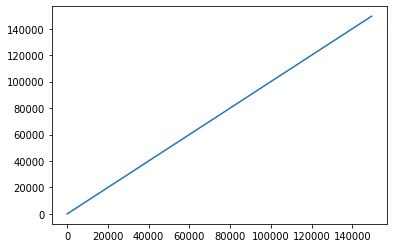

In [7]:
#ещё чуть-чуть походим посмотрим
print(calls['id'].unique())
print(users['user_id'].unique().max())
print(users['reg_date'].min())
print(users['reg_date'].max())
#данные за весь 2018 год, надо проверить нет ли дыры по месяцам. 
#Столбец Unnamed похоже можно просто удалить, совпадает с индексами полностью.
internet['Unnamed: 0'].plot()


<AxesSubplot:>

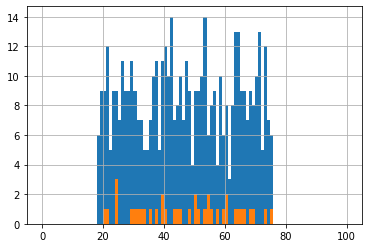

In [8]:
users['age'].hist(bins = 100, range = (0,100))
users[users['churn_date'].notna()]['age'].hist(bins = 100, range = (0,100))
#посмотрим равномерна ли выборка по возрасту и равномерно ли по возрасту распределены те 38 человек, 
#которые отключились от тарифов
#получается все равномерно, выборка не выделяется по возрасту ничем. Она конечно не пропорциональна 
#распределению популяции по возрасту, что, в целом, ничего не значит.  

<AxesSubplot:>

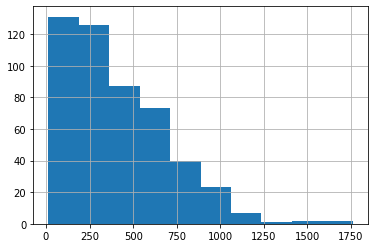

In [9]:
calls['user_id'].value_counts().hist()


95088     38.00
178737    37.35
5865      36.47
39777     36.12
60889     35.95
Name: duration, dtype: float64

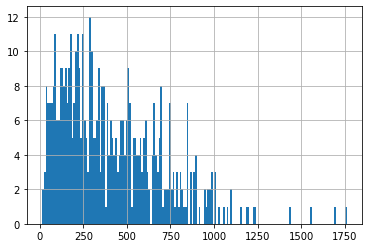

In [10]:
calls['user_id'].value_counts().hist(bins = 175)
#забавно, большая людей делают менее одного звонка в день (менее 350 звонков в год).
display(calls['duration'].sort_values(ascending = False).head())
#Самый длинный звонок за год из всех - 38 минут? Вспоминая свой пубертатный период, в это верится с трудом.

<AxesSubplot:>

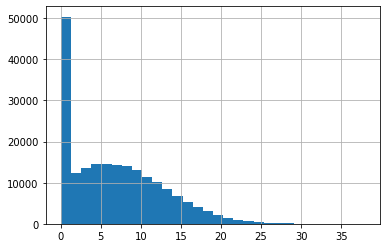

In [11]:
calls['duration'].hist(bins = 30)
#грустно, на лицо нормальное распределение с пиком звонков в ноль секунд 
#в описании есть информация, что это неотвеченные и сброшенные звонки.
#но отсчека оператором связи после 30 минут как бывало раньше не подтверждается....
#Интересно, как выглядела эта выборка в 2012, до массовых звонков через приложения и веб-сервисы....

2018-12-31    1435
2018-12-29    1202
2018-12-30    1192
2018-12-22    1158
2018-12-26    1149
2018-12-18    1141
2018-12-21    1135
2018-12-17    1132
2018-12-14    1128
2018-12-20    1126
2018-12-25    1122
2018-12-24    1114
2018-12-27    1110
2018-12-28    1106
2018-12-08    1105
Name: call_date, dtype: int64

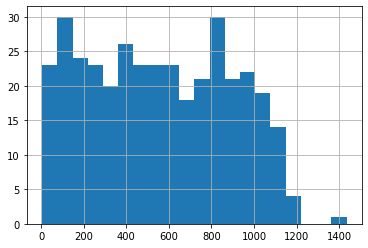

In [12]:
calls['call_date'].value_counts().hist(bins = 20)
calls['call_date'].value_counts().head(15)
#Ноооовый год к нам мчится, 31 числа все поздравляют
#Вообще декабрь выглядит любимым месяцем суетологов. Весь топ-15 дней по звонкам состоит из него.

In [13]:
print(calls['call_date'].value_counts().tail(15))
#как сказал один мой бывший коллега, "in january whole country shuts down for a month"
print(calls['duration'].sum()/500/12)
#ну 228 минут в месяц на человека выглядит правдоподобобно, тем более лично у меня как раз уходит 200-250 минут в месяц.
#без преобразований выборки тут особо смотреть больше нечего, поедем дальше

2018-01-12    37
2018-01-17    37
2018-01-14    36
2018-01-10    35
2018-01-11    34
2018-01-09    31
2018-01-08    31
2018-01-13    30
2018-01-04    23
2018-01-06    21
2018-01-05    20
2018-01-07    18
2018-01-02     9
2018-01-03     7
2018-01-01     5
Name: call_date, dtype: int64
228.1316733333333


In [14]:
print(internet['mb_used'].sum()/1024/1024)
#52 террабайта мобильного трафика в год на 500 пользователей. Выглядит не много.

print(internet['session_date'].value_counts().head(15))
print(internet['session_date'].value_counts().tail(15))
#декабрь просто маслом намазан для мобильных операторов, но в январе, конечно, активность совсем смешная

52.743213396072385
2018-12-31    1057
2018-12-30     903
2018-12-25     859
2018-12-26     844
2018-12-22     834
2018-12-21     833
2018-12-29     825
2018-12-24     820
2018-12-12     816
2018-12-23     808
2018-12-13     805
2018-12-05     804
2018-12-27     803
2018-12-28     802
2018-12-02     801
Name: session_date, dtype: int64
2018-01-19    35
2018-01-10    32
2018-01-15    31
2018-01-14    29
2018-01-11    28
2018-01-08    23
2018-01-12    23
2018-01-09    21
2018-01-06    19
2018-01-07    17
2018-01-05    14
2018-01-04     9
2018-01-03     6
2018-01-01     3
2018-01-02     3
Name: session_date, dtype: int64


In [15]:
print(messages['message_date'].value_counts().head(15))
print(messages['message_date'].value_counts().tail(15))
#тоже самое


2018-12-31    859
2018-12-30    765
2018-12-21    712
2018-12-29    702
2018-12-26    699
2018-12-28    699
2018-12-22    687
2018-12-25    684
2018-12-23    676
2018-12-18    675
2018-12-12    674
2018-12-13    671
2018-12-08    666
2018-11-26    665
2018-12-04    661
Name: message_date, dtype: int64
2018-01-17    26
2018-01-15    23
2018-01-10    22
2018-01-13    22
2018-01-09    21
2018-01-14    21
2018-01-12    17
2018-01-06    15
2018-01-08    14
2018-01-07    12
2018-01-11    12
2018-01-04    10
2018-01-02    10
2018-01-05    10
2018-01-03     4
Name: message_date, dtype: int64


<AxesSubplot:>

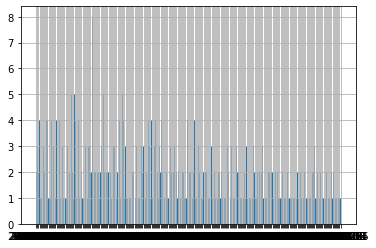

In [16]:
users['reg_date'].hist(bins = 365)
#видно, что ничего не видно, но 
#была мысль, что тарифы объявили в январе 2018 года, потому так мало звонков в начале года
#получается, что равномерно пользователи по году подключались, максимум 5 человек в день зарегистрировалось.
#Получается, пользователи накапливались весь год и почти не отключались от тарифа, потому максимальная активность в декабре, 
#а минимальная - в январе. Надо преобразовать дату регистрации и построить pivot табличку по накопленным юзерам.
#пока не знаю, правда, как это делать, но разберемся ))

In [17]:
print(users['reg_date'].min())
print(users['reg_date'].max())
#Пропусков в reg_date нет, получается, что у нас будет линейное увеличение всего по году, надо держать это в уме
#придется создать счетчик пользователей по дням или месяцам. Жестко, пока не совсем понимаю, как делать выборки 
#с таким набором. Легче конечно, если бы они сразу были все подключены

2018-01-01
2018-12-31


In [18]:
print(users['age'].value_counts().head(5))
print(users['city'].value_counts().head(5))
print(users['first_name'].value_counts().head(5)) # Ну так, интереса ради
print(users['last_name'].value_counts().head(5)) # Ну так, интереса ради
print(users['reg_date'].value_counts().head(5))

53    14
42    14
63    13
64    13
71    13
Name: age, dtype: int64
Москва             99
Санкт-Петербург    39
Новосибирск        16
Казань             14
Омск               14
Name: city, dtype: int64
Радим     6
Леонид    5
Пётр      5
Леон      4
Рубен     4
Name: first_name, dtype: int64
Андреенко    5
Березина     3
Анищенко     3
Булгаков     3
Абашкина     3
Name: last_name, dtype: int64
2018-05-28    8
2018-04-03    5
2018-10-05    5
2018-01-04    5
2018-07-16    5
Name: reg_date, dtype: int64


Очень рандомная выборка, 39 человек из 500 из Петербурга, самое популярное имя Радим, Фамилия - Андреенко, везде низкие значения без выбросов. В этот раз решили нам не усложнять задание и дать приятную выборку. Ну, в целом, не всегда же нам отрабатывать пропуски и поиск дубликатов, в конце концов.

## Подготовка данных

### Найдите и исправьте ошибки в данных
Приведите данные к нужным типам;

Найдите и исправьте ошибки в данных, если они есть.

*Поясните, какие ошибки вы нашли и как их исправили. В данных вы найдёте звонки с нулевой продолжительностью. Это не ошибка: нулями обозначены пропущенные звонки, поэтому их не нужно удалять.

In [19]:
#Как уже говорил, сначала сделаем даты - датами
calls['call_date'] = pd.to_datetime(calls['call_date'], format='%Y-%m-%d')
calls['call_date'].head(15)

0    2018-07-25
1    2018-08-17
2    2018-06-11
3    2018-09-21
4    2018-12-15
5    2018-11-02
6    2018-10-18
7    2018-08-22
8    2018-09-15
9    2018-08-15
10   2018-08-22
11   2018-05-28
12   2018-07-05
13   2018-09-29
14   2018-12-11
Name: call_date, dtype: datetime64[ns]

In [20]:
# все работает, продолжаем
internet['session_date'] = pd.to_datetime(internet['session_date'], format='%Y-%m-%d')
users['reg_date'] = pd.to_datetime(users['reg_date'], format='%Y-%m-%d')
messages['message_date'] = pd.to_datetime(messages['message_date'], format='%Y-%m-%d')
users['churn_date'] = pd.to_datetime(users['churn_date'], format='%Y-%m-%d')
users['reg_date'] = pd.to_datetime(users['reg_date'], format='%Y-%m-%d')

In [21]:
#посмотрим отключившихся от тарифов
display(users[users['churn_date'].notnull()])
#ничего особенного

,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff
19,1019,63,2018-10-05,Томск,Игнатий,Круглов,2018-05-16,ultra
20,1020,59,2018-12-18,Чита,Тала,Костина,2018-10-22,smart
34,1034,66,2018-11-21,Вологда,Святослав,Бондарев,2018-08-26,smart
50,1050,44,2018-10-03,Тюмень,Рузана,Аничкина,2018-06-16,ultra
51,1051,37,2018-10-14,Москва,Кристина,Сомова,2018-05-28,smart
56,1056,73,2018-10-14,Иркутск,Радислав,Артемьев,2018-04-13,smart
62,1062,24,2018-12-09,Москва,Александр,Коршунов,2018-11-16,smart
63,1063,45,2018-12-11,Тула,Таира,Климова,2018-04-12,ultra
64,1064,55,2018-12-26,Якутск,Динара,Алфеева,2018-03-17,smart
65,1065,53,2018-12-09,Москва,Роза,Игнатова,2018-03-08,smart


In [22]:
# Ещё user_id везде является object. В целом, не мешает, но на всякий случай давайте переведем в целое.

calls['user_id'] = calls['user_id'].astype('int')
internet['user_id'] = internet['user_id'].astype('int')
messages['user_id'] = messages['user_id'].astype('int')
users['user_id'] = users['user_id'].astype('int')

In [23]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   age         500 non-null    int64         
 2   churn_date  38 non-null     datetime64[ns]
 3   city        500 non-null    object        
 4   first_name  500 non-null    object        
 5   last_name   500 non-null    object        
 6   reg_date    500 non-null    datetime64[ns]
 7   tariff      500 non-null    object        
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB


In [24]:
#Добавим столбец, в котором будет храниться количество абонентов на дату. Может это нам пригодится.
users_by_date = 0
for x in users['reg_date'].sort_values():
    users_by_date += 1
    users.loc[users['reg_date'] == x, 'users_by_date'] = users_by_date
    
users.head()


,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff,users_by_date
0,1000,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,197.0
1,1001,41,NaT,Москва,Иван,Ежов,2018-11-01,smart,425.0
2,1002,59,NaT,Стерлитамак,Евгений,Абрамович,2018-06-17,smart,227.0
3,1003,23,NaT,Москва,Белла,Белякова,2018-08-17,ultra,322.0
4,1004,68,NaT,Новокузнецк,Татьяна,Авдеенко,2018-05-14,ultra,182.0


In [25]:
users.sort_values(by = 'reg_date').head(5)
#Видимо user_id выдавались специально для этой выборки, потому что не прослеживается очередность как выдавали порядковые номера

,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff,users_by_date
453,1453,50,NaT,Москва,Кузьма,Акуленко,2018-01-01,ultra,2.0
193,1193,55,NaT,Тамбов,Арсен,Безруков,2018-01-01,smart,2.0
55,1055,39,NaT,Казань,Луиза,Березина,2018-01-02,smart,4.0
155,1155,71,NaT,Ставрополь,Александр,Чернов,2018-01-02,smart,4.0
375,1375,53,NaT,Пенза,Мария,Акимычева,2018-01-04,ultra,9.0


<AxesSubplot:xlabel='reg_date'>

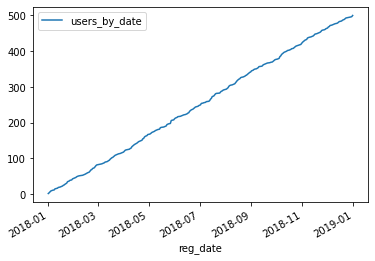

In [26]:
users.plot(x = 'reg_date', y = 'users_by_date' )
#ну ясно понятно, что такое равномерное распределение абонентов по году невозможно, особенности выборки, которые надо учитывать

In [27]:
#выкинем лишний столбец, который дублирует индексы
internet = internet.drop(['Unnamed: 0'], axis=1)
internet.head()

,id,mb_used,session_date,user_id
0,1000_0,112.95,2018-11-25,1000
1,1000_1,1052.81,2018-09-07,1000
2,1000_2,1197.26,2018-06-25,1000
3,1000_3,550.27,2018-08-22,1000
4,1000_4,302.56,2018-09-24,1000


array([[<AxesSubplot:title={'center':'mb_used'}>]], dtype=object)

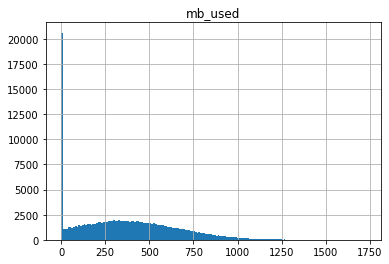

In [28]:
internet.hist(column = 'mb_used', bins = 175)

#но

array([[<AxesSubplot:title={'center':'mb_used'}>]], dtype=object)

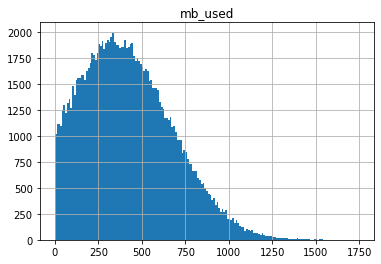

In [29]:
internet.hist(column = 'mb_used', bins = 175, range = (0.1, 1750))



In [30]:
internet['mb_used'].value_counts().head(15)
#нормальное распределение, почти 20 тысяч сессий пустые. Видимо, как и со звонками.

0.00      19598
335.91        9
447.30        9
197.56        9
199.11        8
402.34        8
208.62        8
381.50        8
108.95        8
461.19        8
603.41        8
297.87        8
411.53        8
434.50        8
413.13        8
Name: mb_used, dtype: int64

array([[<AxesSubplot:title={'center':'message_date'}>,
        <AxesSubplot:title={'center':'user_id'}>]], dtype=object)

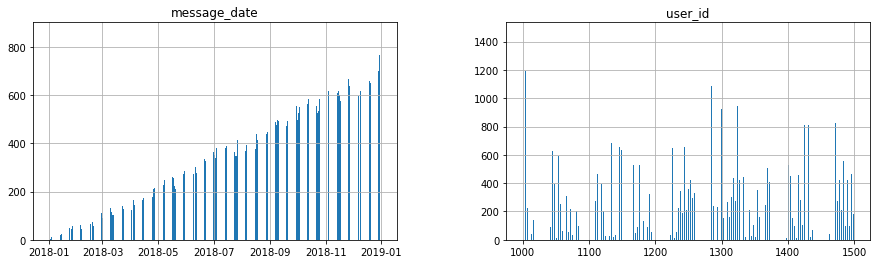

In [31]:
messages.hist(bins = 1500, figsize = (15,4))
#1500 корзин на 1500 абонентов
#Лишь небольшая часть пользователей используют смс, у большинства сообщений почти нет

In [32]:
sms_by_user_id = messages.pivot_table(
    index = 'user_id', values = 'id', aggfunc = 'count')
display(sms_by_user_id.sort_values(by= 'id').tail(15))

,id
user_id,
1471,924
1300,924
1251,935
1396,936
1324,944
1285,1089
1433,1092
1196,1120
1344,1125


In [33]:
users['tariff'].describe()
#351 из 500 сидят на тарифе смарт, 149 на тарифе ультра.

count       500
unique        2
top       smart
freq        351
Name: tariff, dtype: object

### Расчет использованных услуг по пользователям в месяц

Посчитайте для каждого пользователя:
1) количество сделанных звонков и израсходованных минут разговора по месяцам;

2) количество отправленных сообщений по месяцам;

3) объем израсходованного интернет-трафика по месяцам;

4) помесячную выручку с каждого пользователя (вычтите бесплатный лимит из суммарного количества звонков, сообщений и интернет-трафика; остаток умножьте на значение из тарифного плана; прибавьте абонентскую плату, соответствующую тарифному плану).

In [34]:
#во первых, как мы знаем, каждый звонок округляется вверх до минуты, потому для счета количества минут 
#нужно округлить минуты вверх. Если что - перезагрузим датасет 
   
calls['duration'] = np.ceil(calls['duration']).astype(int)
print(calls['duration'].head())
#во сторых добавим столбец с месяцем, чтобы выполнить задание

calls['month'] = pd.DatetimeIndex(calls['call_date']).month
#посчитаем количество "израсходованных" (округленных) минут 
total_calls_by_month_by_user = calls[calls['duration'] > 0].pivot_table(
    index = ['month', 'user_id'], values = 'duration', aggfunc = ['count', 'sum'])
total_calls_by_month_by_user.columns = ['calls_count', 'calls_duration']

display(total_calls_by_month_by_user)

0     0
1     0
2     3
3    14
4     6
Name: duration, dtype: int64


calls_count  calls_duration
month user_id                             
1     1005              11              95
      1032              44             380
      1045               1               9
      1055              47             551
      1071              18             194
...                    ...             ...
12    1494              54             418
      1495             120            1031
      1496              65             518
      1497              58             545
      1499              56             492

[3168 rows x 2 columns]

In [35]:
#вообещем-то первое задание выполнено, только график хочется построить.
#всё очень линейно, среднестатистический абонент остается среднестатистическим
total_calls_by_month_by_user.corr()

,calls_count,calls_duration
calls_count,1.000000,0.987356
calls_duration,0.987356,1.000000


In [36]:
#количетсво сообщений по месяцам тоже посчитаем


messages['month'] = pd.DatetimeIndex(messages['message_date']).month
#посчитаем количество "израсходованных" (округленных) минут 
total_msg_by_month_by_user = messages.pivot_table(
    index = ['month', 'user_id'], values = 'id', aggfunc = 'count')
total_msg_by_month_by_user.columns = ['msg_count']

display(total_msg_by_month_by_user)

msg_count
month user_id           
1     1005             7
      1032            38
      1045             5
      1055            30
      1071            16
...                  ...
12    1493            78
      1495            84
      1496            51
      1497            17
      1499            66

[2717 rows x 1 columns]

In [37]:
total_msg_by_month_by_user.loc[12, 1493]

msg_count    78
Name: (12, 1493), dtype: int64

In [38]:
#Посчитаем объем израсходованного интернет-трафика по месяцам...
#пока, насколько я понимаю, не нужно округлять трафик на данном этапе
internet['month'] = pd.DatetimeIndex(internet['session_date']).month

total_internet_by_month = internet.pivot_table(
    index = ['month', 'user_id'], values = 'mb_used', aggfunc = 'sum')
display(total_internet_by_month)

mb_used
month user_id          
1     1005      2727.97
      1032     24127.69
      1045      2346.71
      1055     17090.88
      1071     15604.34
...                 ...
12    1494     17621.21
      1495     23426.76
      1496     20736.15
      1497     19918.60
      1499     13055.58

[3203 rows x 1 columns]

In [39]:
#создадим таблицу с тратами интернета по месяцам, по гигабайтам
total_internet_by_month_by_users = internet.pivot_table(
    index = ['month', 'user_id'], values = 'mb_used', aggfunc = 'sum')
display(total_internet_by_month_by_users)
for index, value in total_internet_by_month_by_users.items():
    total_internet_by_month_by_users = (total_internet_by_month_by_users/1024).apply(np.ceil).astype(int) 
    #я сам не понимаю как работаект условие выше, но главное, что работает )
total_internet_by_month_by_users.columns = ['gb_used']

display(total_internet_by_month_by_users)


mb_used
month user_id          
1     1005      2727.97
      1032     24127.69
      1045      2346.71
      1055     17090.88
      1071     15604.34
...                 ...
12    1494     17621.21
      1495     23426.76
      1496     20736.15
      1497     19918.60
      1499     13055.58

[3203 rows x 1 columns]

gb_used
month user_id         
1     1005           3
      1032          24
      1045           3
      1055          17
      1071          16
...                ...
12    1494          18
      1495          23
      1496          21
      1497          20
      1499          13

[3203 rows x 1 columns]

In [40]:
#сведем в общую таблицу
users_monthly_activity = total_calls_by_month_by_user.join(total_msg_by_month_by_user, how = 'outer')

display(users_monthly_activity)

calls_count  calls_duration  msg_count
month user_id                                        
1     1005            11.0            95.0        7.0
      1032            44.0           380.0       38.0
      1045             1.0             9.0        5.0
      1055            47.0           551.0       30.0
      1071            18.0           194.0       16.0
...                    ...             ...        ...
12    1494            54.0           418.0        NaN
      1495           120.0          1031.0       84.0
      1496            65.0           518.0       51.0
      1497            58.0           545.0       17.0
      1499            56.0           492.0       66.0

[3212 rows x 3 columns]

In [41]:
#добавим интернет
users_monthly_activity = users_monthly_activity.join(total_internet_by_month_by_users, how = 'outer')
display(users_monthly_activity)

calls_count  calls_duration  msg_count  gb_used
month user_id                                                 
1     1005            11.0            95.0        7.0      3.0
      1032            44.0           380.0       38.0     24.0
      1045             1.0             9.0        5.0      3.0
      1055            47.0           551.0       30.0     17.0
      1071            18.0           194.0       16.0     16.0
...                    ...             ...        ...      ...
12    1494            54.0           418.0        NaN     18.0
      1495           120.0          1031.0       84.0     23.0
      1496            65.0           518.0       51.0     21.0
      1497            58.0           545.0       17.0     20.0
      1499            56.0           492.0       66.0     13.0

[3214 rows x 4 columns]

In [42]:
#хирургическая операция по добавлению тарифа к пользователям
user_tariffs = pd.DataFrame()
user_tariffs['user_id'] = users['user_id']
user_tariffs['tariff'] = users['tariff']
user_tariffs = user_tariffs.set_index('user_id')
users_monthly_activity = users_monthly_activity.join(user_tariffs, how = 'outer')
#стработало вроде
display(user_tariffs)
display(users_monthly_activity)

,tariff
user_id,
1000,ultra
1001,smart
1002,smart
1003,ultra
1004,ultra
...,...
1495,ultra
1496,smart
1497,smart


calls_count  calls_duration  msg_count  gb_used tariff
month user_id                                                        
1     1005            11.0            95.0        7.0      3.0  smart
      1032            44.0           380.0       38.0     24.0  smart
      1045             1.0             9.0        5.0      3.0  smart
      1055            47.0           551.0       30.0     17.0  smart
      1071            18.0           194.0       16.0     16.0  smart
...                    ...             ...        ...      ...    ...
12    1494            54.0           418.0        NaN     18.0  smart
      1495           120.0          1031.0       84.0     23.0  ultra
      1496            65.0           518.0       51.0     21.0  smart
      1497            58.0           545.0       17.0     20.0  smart
      1499            56.0           492.0       66.0     13.0  smart

[3214 rows x 5 columns]

In [43]:
#посмотрим, как изменялось количество пользователей с течением года
for x in range (1,13):
    print(len(users_monthly_activity.loc[x, :]))

43
82
114
167
208
248
292
342
375
417
450
476


In [44]:
#невозможно работать с такими индексами, надо их убрать.
users_monthly_activity = users_monthly_activity.reset_index()
display(users_monthly_activity)
#получилось
users_monthly_activity.describe()

,month,user_id,calls_count,calls_duration,msg_count,gb_used,tariff
0,1,1005,11.0,95.0,7.0,3.0,smart
1,1,1032,44.0,380.0,38.0,24.0,smart
2,1,1045,1.0,9.0,5.0,3.0,smart
3,1,1055,47.0,551.0,30.0,17.0,smart
4,1,1071,18.0,194.0,16.0,16.0,smart
...,...,...,...,...,...,...,...
3209,12,1494,54.0,418.0,NaN,18.0,smart
3210,12,1495,120.0,1031.0,84.0,23.0,ultra
3211,12,1496,65.0,518.0,51.0,21.0,smart
3212,12,1497,58.0,545.0,17.0,20.0,smart


,month,user_id,calls_count,calls_duration,msg_count,gb_used
count,3214.000000,3214.000000,3168.000000,3168.000000,2717.000000,3203.000000
mean,8.317362,1251.590230,51.450126,457.797033,45.283769,17.358414
std,2.905413,144.659172,26.439188,237.423514,35.051363,7.343379
min,1.000000,1000.000000,1.000000,1.000000,1.000000,0.000000
25%,6.000000,1125.000000,33.000000,290.750000,19.000000,13.000000
50%,9.000000,1253.000000,50.000000,447.500000,38.000000,17.000000
75%,11.000000,1378.750000,67.000000,592.250000,63.000000,21.000000
max,12.000000,1499.000000,190.000000,1673.000000,224.000000,49.000000


In [45]:
#заполним пропуски нулями. Если там не было звонков или сообщений - значит это ноль.
users_monthly_activity = users_monthly_activity.fillna(value = 0)
users_monthly_activity.describe()


,month,user_id,calls_count,calls_duration,msg_count,gb_used
count,3214.000000,3214.000000,3214.000000,3214.000000,3214.000000,3214.000000
mean,8.317362,1251.590230,50.713752,451.244866,38.281269,17.299004
std,2.905413,144.659172,26.951413,241.909978,36.148326,7.400584
min,1.000000,1000.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,1125.000000,32.000000,282.000000,9.000000,13.000000
50%,9.000000,1253.000000,50.000000,443.000000,30.000000,17.000000
75%,11.000000,1378.750000,66.000000,589.000000,57.000000,21.000000
max,12.000000,1499.000000,190.000000,1673.000000,224.000000,49.000000


####  Помесячная выручку с каждого пользователя

Посчитайте для каждого пользователя:

4) помесячную выручку с каждого пользователя (вычтите бесплатный лимит из суммарного количества звонков, сообщений и интернет-трафика; остаток умножьте на значение из тарифного плана; прибавьте абонентскую плату, соответствующую тарифному плану).

In [46]:
#Пишем большой нудный цикл со ссылками на тектовик "tarrifs", потому что так будет, наверное, правильно

for index, row in users_monthly_activity.iterrows(): #своровал в интернете функцию
    if row['tariff'] == 'smart':
        revenue = tariffs.loc[0, 'rub_monthly_fee']
        if (users_monthly_activity.loc[index, 'calls_duration'] - tariffs.loc[0, 'minutes_included']) > 0:
            revenue = revenue + (users_monthly_activity.loc[index, 'calls_duration'] - tariffs.loc[0, 'minutes_included'])*tariffs.loc[0, 'rub_per_minute']
        if (users_monthly_activity.loc[index, 'msg_count'] - tariffs.loc[0, 'messages_included']) > 0:
            revenue = revenue + (users_monthly_activity.loc[index, 'msg_count'] - tariffs.loc[0, 'messages_included'])*tariffs.loc[0, 'rub_per_message']
        if (users_monthly_activity.loc[index, 'gb_used'] - 15) > 0:
            revenue = revenue + (users_monthly_activity.loc[index, 'gb_used'] - 15)*tariffs.loc[0, 'rub_per_gb']           
    else:
        revenue = tariffs.loc[1, 'rub_monthly_fee']
        if (users_monthly_activity.loc[index, 'calls_duration'] - tariffs.loc[1, 'minutes_included']) > 0:
            revenue = revenue + (users_monthly_activity.loc[index, 'calls_duration'] - tariffs.loc[1, 'minutes_included'])*tariffs.loc[1, 'rub_per_minute']
        if (users_monthly_activity.loc[index, 'msg_count'] - tariffs.loc[1, 'messages_included']) > 0:
            revenue = revenue + (users_monthly_activity.loc[index, 'msg_count'] - tariffs.loc[1, 'minutes_included'])*tariffs.loc[1, 'rub_per_message']
        if (users_monthly_activity.loc[index, 'gb_used'] - 30) > 0:
            revenue = revenue + (users_monthly_activity.loc[index, 'gb_used'] - 30)*tariffs.loc[1, 'rub_per_gb']           
    users_monthly_activity.loc[index, 'revenue'] = revenue
users_monthly_activity.head(15)
# к сожалению, я уже перевел в таблице мегабайты в гигабайты и пришлось вместо ссылки на таблицу "тариф" использовать константу

,month,user_id,calls_count,calls_duration,msg_count,gb_used,tariff,revenue
0,1,1005,11.0,95.0,7.0,3.0,smart,550.0
1,1,1032,44.0,380.0,38.0,24.0,smart,2350.0
2,1,1045,1.0,9.0,5.0,3.0,smart,550.0
3,1,1055,47.0,551.0,30.0,17.0,smart,1103.0
4,1,1071,18.0,194.0,16.0,16.0,smart,750.0
5,1,1113,13.0,110.0,14.0,1.0,smart,550.0
6,1,1120,4.0,55.0,0.0,1.0,ultra,1950.0
7,1,1126,28.0,272.0,4.0,16.0,ultra,1950.0
8,1,1134,33.0,332.0,32.0,10.0,smart,550.0
9,1,1135,9.0,90.0,1.0,2.0,smart,550.0


In [47]:
users_monthly_activity.query('revenue < 550')
#Проверка на ошибки, может где неверно посчитал прибыль.

,month,user_id,calls_count,calls_duration,msg_count,gb_used,tariff,revenue


In [48]:
revenue_by_tariff = users_monthly_activity.pivot_table(
    index = ['month', 'tariff'] , values = 'revenue', aggfunc = ['count', 'mean', 'median'])
revenue_by_tariff
#просто посмотрим

count         mean  median
             revenue      revenue revenue
month tariff                             
1     smart       34   721.323529   550.0
      ultra        9  1950.000000  1950.0
2     smart       58   827.603448   550.0
      ultra       24  1975.000000  1950.0
3     smart       77  1164.623377   886.0
      ultra       37  2014.864865  1950.0
4     smart      112   963.089286   620.5
      ultra       55  2001.818182  1950.0
5     smart      141  1197.510638   986.0
      ultra       67  2059.701493  1950.0
6     smart      164  1204.018293   950.0
      ultra       84  2039.285714  1950.0
7     smart      201  1223.950249   981.0
      ultra       91  2118.131868  1950.0
8     smart      235  1320.595745  1079.0
      ultra      107  2083.177570  1950.0
9     smart      260  1249.946154   958.5
      ultra      115  2024.347826  1950.0
10    smart      294  1364.853741  1150.0
      ultra      123  2065.853659  1950.0
11    smart      316  1343.047468  1150.0
      ultra      134  2092.164179  1950.0
12    smart      337  1578.531157  1277.0
      ultra      139  2138.848921  1950.0

In [49]:
#попробуем объеденить данные из таблиц с выручкой и таблицы с данными по "user_id"

users_monthly_activity = users_monthly_activity.merge(users, how='outer', on = 'user_id')
users_monthly_activity

,month,user_id,calls_count,calls_duration,msg_count,gb_used,tariff_x,revenue,age,churn_date,city,first_name,last_name,reg_date,tariff_y,users_by_date
0,1.0,1005,11.0,95.0,7.0,3.0,smart,550.0,67,NaT,Набережные Челны,Афанасий,Горлов,2018-01-25,smart,36.0
1,2.0,1005,55.0,456.0,38.0,8.0,smart,550.0,67,NaT,Набережные Челны,Афанасий,Горлов,2018-01-25,smart,36.0
2,3.0,1005,63.0,606.0,56.0,11.0,smart,886.0,67,NaT,Набережные Челны,Афанасий,Горлов,2018-01-25,smart,36.0
3,4.0,1005,77.0,712.0,41.0,10.0,smart,1186.0,67,NaT,Набережные Челны,Афанасий,Горлов,2018-01-25,smart,36.0
4,5.0,1005,62.0,595.0,42.0,8.0,smart,835.0,67,NaT,Набережные Челны,Афанасий,Горлов,2018-01-25,smart,36.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3211,12.0,1434,65.0,560.0,21.0,15.0,smart,730.0,73,NaT,Москва,Карина,Субботина,2018-12-14,smart,481.0
3212,12.0,1445,54.0,508.0,75.0,17.0,smart,1049.0,40,NaT,Москва,Рауль,Иванов,2018-12-29,smart,496.0
3213,12.0,1485,72.0,584.0,155.0,23.0,ultra,1950.0,34,NaT,Киров,Таисия,Сухова,2018-12-29,ultra,496.0
3214,NaN,1128,NaN,NaN,NaN,NaN,NaN,NaN,51,2018-12-23,Волжский,Ксения,Агаева,2018-12-15,ultra,483.0


In [50]:
users_monthly_activity[users_monthly_activity['revenue'].isna()]
#у нас из таблицы выпали два человека, которые не воспользовались своей сим-картой и отключили тариф... 
#будем считать, что эти 2 точки выборки из 3214 можно выкинуть )))

,month,user_id,calls_count,calls_duration,msg_count,gb_used,tariff_x,revenue,age,churn_date,city,first_name,last_name,reg_date,tariff_y,users_by_date
3214,NaN,1128,NaN,NaN,NaN,NaN,NaN,NaN,51,2018-12-23,Волжский,Ксения,Агаева,2018-12-15,ultra,483.0
3215,NaN,1371,NaN,NaN,NaN,NaN,NaN,NaN,50,2018-12-30,Омск,Ириней,Трофимов,2018-12-25,smart,494.0


In [51]:
users_monthly_activity = users_monthly_activity.drop(index = [3214, 3215])
users_monthly_activity = users_monthly_activity.drop(['tariff_y'], axis=1)
users_monthly_activity = users_monthly_activity.rename(columns={"tariff_x": "tariff", "msg_count": "msg_sent"})
users_monthly_activity

,month,user_id,calls_count,calls_duration,msg_sent,gb_used,tariff,revenue,age,churn_date,city,first_name,last_name,reg_date,users_by_date
0,1.0,1005,11.0,95.0,7.0,3.0,smart,550.0,67,NaT,Набережные Челны,Афанасий,Горлов,2018-01-25,36.0
1,2.0,1005,55.0,456.0,38.0,8.0,smart,550.0,67,NaT,Набережные Челны,Афанасий,Горлов,2018-01-25,36.0
2,3.0,1005,63.0,606.0,56.0,11.0,smart,886.0,67,NaT,Набережные Челны,Афанасий,Горлов,2018-01-25,36.0
3,4.0,1005,77.0,712.0,41.0,10.0,smart,1186.0,67,NaT,Набережные Челны,Афанасий,Горлов,2018-01-25,36.0
4,5.0,1005,62.0,595.0,42.0,8.0,smart,835.0,67,NaT,Набережные Челны,Афанасий,Горлов,2018-01-25,36.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3209,12.0,1398,37.0,310.0,13.0,19.0,smart,1350.0,58,NaT,Махачкала,Рауль,Ахмедов,2018-12-06,473.0
3210,12.0,1406,34.0,290.0,21.0,12.0,smart,550.0,68,NaT,Казань,Станислав,Семёнов,2018-12-15,483.0
3211,12.0,1434,65.0,560.0,21.0,15.0,smart,730.0,73,NaT,Москва,Карина,Субботина,2018-12-14,481.0
3212,12.0,1445,54.0,508.0,75.0,17.0,smart,1049.0,40,NaT,Москва,Рауль,Иванов,2018-12-29,496.0


## Анализ данных

Опишите поведение клиентов оператора, исходя из выборки. Сколько минут разговора, сколько сообщений и какой объём интернет-трафика требуется пользователям каждого тарифа в месяц? Посчитайте среднее количество, дисперсию и стандартное отклонение. Постройте гистограммы. Опишите распределения.

count    2229.000000
mean      417.934948
std       190.313730
min         0.000000
25%       282.000000
50%       422.000000
75%       545.000000
max      1435.000000
Name: calls_duration, dtype: float64

 Дисперсия минут в месяц тарифа смарт равна  36219.31578434428


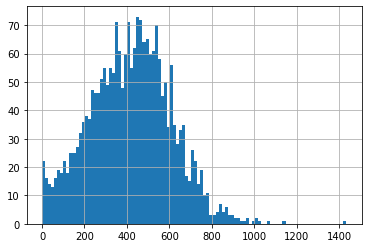

In [52]:
#посмотрим, сколько минут в месяц общаются пользователи тарифа смарт
users_monthly_activity[users_monthly_activity['tariff'] == 'smart']['calls_duration'].hist(bins = 100)
display(users_monthly_activity[users_monthly_activity['tariff'] == 'smart']['calls_duration'].describe())
print(' Дисперсия минут в месяц тарифа смарт равна ', 
      np.var(users_monthly_activity[users_monthly_activity['tariff'] == 'smart']['calls_duration'], ddof=1))
#У нас выборка, а значит у нас не дисперсия, а её оценка
#Хотел я, конечно, взять стандартное отклонение из describe(), да в квадрат возвести, но наверное стоит вызвать функцию...

count     985.000000
mean      526.623350
std       317.606098
min         0.000000
25%       284.000000
50%       518.000000
75%       752.000000
max      1673.000000
Name: calls_duration, dtype: float64

 Дисперсия минут в месяц тарифа ультра равна  100873.63339730098


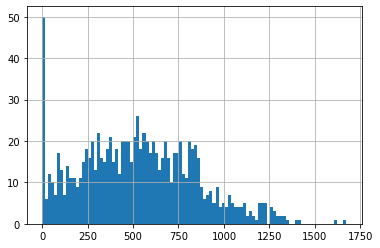

In [53]:
#посмотрим, сколько минут в месяц общаются пользователи тарифа ультра
users_monthly_activity[users_monthly_activity['tariff'] == 'ultra']['calls_duration'].hist(bins = 100)
display(users_monthly_activity[users_monthly_activity['tariff'] == 'ultra']['calls_duration'].describe())
print(' Дисперсия минут в месяц тарифа ультра равна ', 
      np.var(users_monthly_activity[users_monthly_activity['tariff'] == 'ultra']['calls_duration'], ddof=1))

<AxesSubplot:>

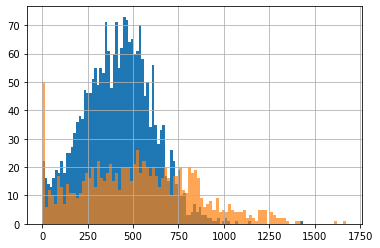

In [54]:
users_monthly_activity[users_monthly_activity['tariff'] == 'smart']['calls_duration'].hist(bins = 100)
users_monthly_activity[users_monthly_activity['tariff'] == 'ultra']['calls_duration'].hist(bins = 100, alpha = 0.7)


count    2229.000000
mean       33.384029
std        28.227876
min         0.000000
25%        10.000000
50%        28.000000
75%        51.000000
max       143.000000
Name: msg_sent, dtype: float64

 Дисперсия количества сообщений в месяц тарифа смарт равна  796.8129584480083


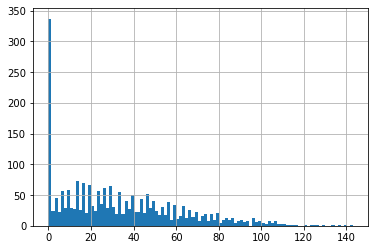

In [55]:
#посмотрим, сколько сообщений в месяц используют пользователи тарифа смарт
users_monthly_activity[users_monthly_activity['tariff'] == 'smart']['msg_sent'].hist(bins = 100)
display(users_monthly_activity[users_monthly_activity['tariff'] == 'smart']['msg_sent'].describe())
print(' Дисперсия количества сообщений в месяц тарифа смарт равна ', 
      np.var(users_monthly_activity[users_monthly_activity['tariff'] == 'smart']['msg_sent'], ddof=1))

count    985.000000
mean      49.363452
std       47.804457
min        0.000000
25%        6.000000
50%       38.000000
75%       79.000000
max      224.000000
Name: msg_sent, dtype: float64

 Дисперсия количества сообщений в месяц тарифа ультра равна  2285.2661425446745


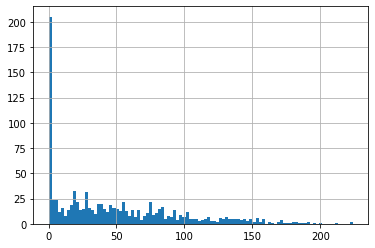

In [56]:
#посмотрим, сколько сообщений в месяц используют пользователи тарифа ультра
users_monthly_activity[users_monthly_activity['tariff'] == 'ultra']['msg_sent'].hist(bins = 100)
display(users_monthly_activity[users_monthly_activity['tariff'] == 'ultra']['msg_sent'].describe())
print(' Дисперсия количества сообщений в месяц тарифа ультра равна ', 
      np.var(users_monthly_activity[users_monthly_activity['tariff'] == 'ultra']['msg_sent'], ddof=1))
#нули нам очень сильно портят выборку, стандартное отклонение практически равно среднему...
#Ну мы же не можем просто выкинуть тех, кто не пользуется сообщениями? Я не знаю, но думаю, что нет.

count    2229.000000
mean       16.328847
std         5.747061
min         0.000000
25%        13.000000
50%        17.000000
75%        20.000000
max        38.000000
Name: gb_used, dtype: float64

 Дисперсия количества трафика в месяц а Гб тарифа смарт равна  33.02870517811161


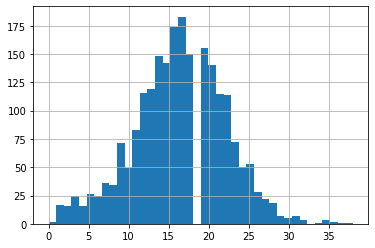

In [57]:
#посмотрим, сколько интернета в месяц используют пользователи тарифа смарт
users_monthly_activity[users_monthly_activity['tariff'] == 'smart']['gb_used'].hist(bins = 40)
display(users_monthly_activity[users_monthly_activity['tariff'] == 'smart']['gb_used'].describe())
print(' Дисперсия количества трафика в месяц а Гб тарифа смарт равна ', 
      np.var(users_monthly_activity[users_monthly_activity['tariff'] == 'smart']['gb_used'], ddof=1))

count    985.000000
mean      19.494416
std        9.853511
min        0.000000
25%       12.000000
50%       19.000000
75%       27.000000
max       49.000000
Name: gb_used, dtype: float64

 Дисперсия количества трафика в месяц а Гб тарифа ультра равна  97.09168626965457


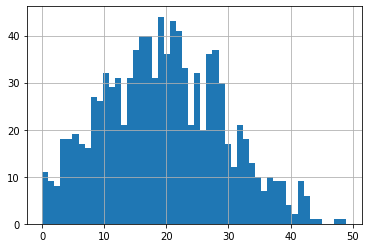

In [58]:
#посмотрим, сколько интернета в месяц используют пользователи тарифа ультра
users_monthly_activity[users_monthly_activity['tariff'] == 'ultra']['gb_used'].hist(bins = 50)
display(users_monthly_activity[users_monthly_activity['tariff'] == 'ultra']['gb_used'].describe())
print(' Дисперсия количества трафика в месяц а Гб тарифа ультра равна ', 
      np.var(users_monthly_activity[users_monthly_activity['tariff'] == 'ultra']['gb_used'], ddof=1))

count     2228.000000
mean     16215.661849
std       5861.736234
min          0.000000
25%      12649.272500
50%      16507.740000
75%      20043.792500
max      38552.450000
Name: mb_used, dtype: float64

 Дисперсия количества трафика в месяц а Мб тарифа смарт равна  34359951.682283156


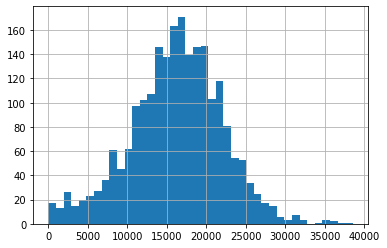

In [59]:
#Посмотрим в мегабайтах на всякий случай
#пересоздадим таблицу
#Проверим параметры интернета на тарифе смарт
total_internet_by_month_by_users_in_mb = internet.pivot_table(
    index = ['month', 'user_id'], values = 'mb_used', aggfunc = 'sum')
total_internet_by_month_by_users_in_mb = total_internet_by_month_by_users_in_mb.join(user_tariffs, how = 'outer')
total_internet_by_month_by_users_in_mb = total_internet_by_month_by_users_in_mb.reset_index()
total_internet_by_month_by_users_in_mb[total_internet_by_month_by_users_in_mb['tariff'] == 'smart']['mb_used'].hist(bins = 40)
display(total_internet_by_month_by_users_in_mb[total_internet_by_month_by_users_in_mb['tariff'] == 'smart']['mb_used'].describe())


#Что-то разницы особой я не вижу 
print(' Дисперсия количества трафика в месяц а Мб тарифа смарт равна ', 
      np.var(total_internet_by_month_by_users_in_mb[total_internet_by_month_by_users_in_mb['tariff'] == 'smart']['mb_used'], ddof=1))

count      975.000000
mean     19668.485262
std       9943.050284
min          0.000000
25%      12008.305000
50%      19394.290000
75%      26896.550000
max      49745.690000
Name: mb_used, dtype: float64

 Дисперсия количества трафика в месяц а Мб тарифа ультра равна  98864248.95263155


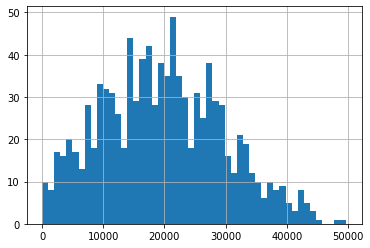

In [60]:
total_internet_by_month_by_users_in_mb[total_internet_by_month_by_users_in_mb['tariff'] == 'ultra']['mb_used'].hist(bins = 50)
display(total_internet_by_month_by_users_in_mb[total_internet_by_month_by_users_in_mb['tariff'] == 'ultra']['mb_used'].describe())
print(' Дисперсия количества трафика в месяц а Мб тарифа ультра равна ', 
      np.var(total_internet_by_month_by_users_in_mb[total_internet_by_month_by_users_in_mb['tariff'] == 'ultra']['mb_used'], ddof=1))

|Параметр| Звонки, тариф смарт, мин|Звонки, тариф ультра, мин|Сообщения, тариф смарт|Сообщения, тариф ультра|Интернет, тариф смарт, Гб|Интернет, тариф ультра, Гб|
|-------|-------|-------|-------|-------|-------|-------|
| Среднее                 | 417.9      | 526.6         | 33.4 | 49.4      | 16.3         | 19.5       
| Стандартное отклонение  | 190.3       | 317.6          | 28.2 | 47.8       | 5.74          | 9.85  
| Оценка дисперсии*       | 36219.3       | 100873.6          | 796.8  | 2285.3       | 33.0          | 97.1   


1) Пользователи тарифа ультра потребляют всех видов услуг больше, чем пользователи тарифа смарт.
    
    
2) При этом стоит отметить, что цена между тарифами различается в 3.5 раза, при этом среднее потребление услуг выше всего на 20-30%
    
    
3) Оценка дисперсии и стандартное отклонение параметров на тарифе ультра значительно больше, чем на тарифе смарт. Это означает, что разброс потребления услуг между пользователями тарифа ультра значительно сильнее, чем у тарифа смарт. Т.е. если у пользователей тарифа смарт ярко выраженный пик потребления на 16 Гб траффика в месяц, что хорошо согласуется со средним значением, то у пользователей тарифа ультра пик менее выражен, разброс по использованию трафика гораздо шире.
    
    
    
4) На тарифе смарт более 50% пользователей докупают интернет свыше лимита 15Гб, при этом на тарифе ультра около 80% пользователей укладываются в тарифный лимит 30ГБ.
    
    
5) БольшАя часть пользователей не пользуется отправкой сообщений. На тарифе смарт в лимит сообщений укладываются 75% пользователей, на тарифе ультра никто не использует полностью включенный пакет в 1000 сообщений (максимальное значение - 224 смс в месяц).
    
    
6) Почти та же ситуация со звонками. Около 60% пользователей тарифа смарт укладываются в лимит звонков, но никто из пользователей тарифа ультра не использует полностью включенный пакет в 3000 минут (максимальное значение - 1673)
    
    
7) Из-за большого искажения нормальности выборки по количеству использованных СМС - пик около нуля - стандартное отклонение очень велико. Особенно хорошо это видно на пользователях тарифа ультра, где стандартное отклонение практически равно среднему. 
    
    
8) Стоит так же отметить, что на распределении количества звонков в месяц правая часть нормального распределения спадает значительно быстрее, чем, например, на распределении количества использованного трафика. Это может говорит о том, что пользователи тарифа смарт не хотят переплачивать за звонки и снижают потребления данной услуги при превышении лимита. Но при этом они с гораздо большим желанием переплачивают за интернет. 

#### Правка 4

In [61]:
#добавим анализ выручки по тарифам
revenue_by_tariff_new = users_monthly_activity.pivot_table(
    index = 'tariff' , values = 'revenue', aggfunc = ['count', 'mean', 'median', sum])
revenue_by_tariff_new


,count,mean,median,sum
,revenue,revenue,revenue,revenue
tariff,,,,
smart,2229,1289.973531,1023.0,2875351.0
ultra,985,2070.152284,1950.0,2039100.0


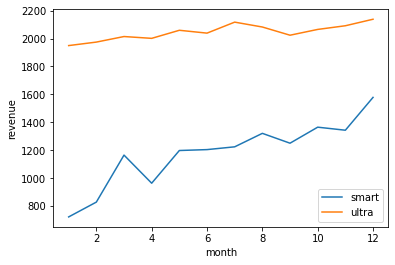

In [62]:
#сравним среднюю выручку по тарифам по месяцам
users_monthly_activity.query('tariff == "smart"').groupby(by = 'month').mean()['revenue'].plot(legend = True, label = 'smart')
users_monthly_activity.query('tariff == "ultra"').groupby(by = 'month').mean()['revenue'].plot(legend = True, ylabel = 'revenue', label = 'ultra')
plt.show()


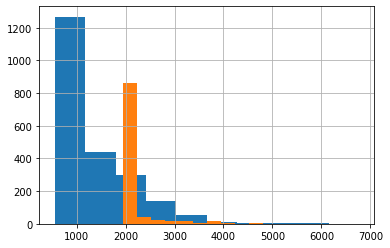

In [63]:
#сравним выручку по тарифам. Видимо, что гораздо больше пользователей тарифа смарт приносят более 1950 рублей, 
#чем на тарифе ультра
users_monthly_activity.query('tariff == "smart"')['revenue'].hist(label = 'smart')
users_monthly_activity.query('tariff == "ultra"')['revenue'].hist(label = 'ultra')
plt.show()

In [64]:
#видно, больше всего платят на тарифе смарт.
users_monthly_activity.sort_values(by = 'revenue', ascending = False).head(20)

,month,user_id,calls_count,calls_duration,msg_sent,gb_used,tariff,revenue,age,churn_date,city,first_name,last_name,reg_date,users_by_date
3092,12.0,1486,115.0,1007.0,83.0,38.0,smart,6770.0,35,NaT,Нижний Новгород,Матвей,Моргунов,2018-10-31,422.0
3107,12.0,1042,94.0,728.0,75.0,37.0,smart,5709.0,42,NaT,Хабаровск,Константин,Добрынин,2018-11-25,459.0
3091,11.0,1486,84.0,764.0,96.0,36.0,smart,5680.0,35,NaT,Нижний Новгород,Матвей,Моргунов,2018-10-31,422.0
3035,12.0,1261,113.0,1074.0,22.0,32.0,smart,5672.0,46,NaT,Казань,Мадина,Пантелеева,2018-10-30,419.0
3147,12.0,1286,83.0,739.0,68.0,35.0,smart,5321.0,19,NaT,Москва,Рашид,Троицкий,2018-11-27,460.0
3127,12.0,1159,85.0,734.0,2.0,35.0,smart,5252.0,64,NaT,Красноярск,Эльга,Аничкина,2018-11-28,461.0
2125,12.0,1098,63.0,588.0,14.0,36.0,smart,5014.0,39,NaT,Челябинск,Элеонора,Озерова,2018-06-23,238.0
2841,10.0,1124,130.0,1225.0,121.0,49.0,ultra,4800.0,54,NaT,Махачкала,Альбин,Андрианов,2018-09-24,369.0
3034,11.0,1261,82.0,738.0,25.0,32.0,smart,4664.0,46,NaT,Казань,Мадина,Пантелеева,2018-10-30,419.0
657,8.0,1240,49.0,457.0,0.0,48.0,ultra,4650.0,30,NaT,Воронеж,Зинаида,Шарова,2018-02-27,80.0


In [65]:
#сколько раз пользователи разных тарифов платили выше 1950 рублей за услуги в месяц?
users_monthly_activity.query('revenue > 1950')['tariff'].value_counts()

smart    417
ultra    134
Name: tariff, dtype: int64

In [66]:
#выручка от пользователей тарифа смарт, которые платили выше абоненсткой платы тарифа ультра
#и выручка от пользователей тарифа ультра, которые платят сверх абоненской платы
print(users_monthly_activity.query('revenue > 1950 and tariff == "smart"')['revenue'].sum())
print(users_monthly_activity.query('revenue > 1950 and tariff == "ultra"')['revenue'].sum())


1105302.0
379650.0


In [67]:
#посмотрим процент пользователей на разных тарифах, которые платили выше 1950 рублей на разных тарифах
print(users_monthly_activity.query('revenue > 1950 and tariff == "smart"')['revenue'].count() / users_monthly_activity.query('tariff == "smart"')['revenue'].count())
print(users_monthly_activity.query('revenue > 1950 and tariff == "ultra"')['revenue'].count() / users_monthly_activity.query('tariff == "ultra"')['revenue'].count())
#получается на тарифе смарт выше процент пользователей, котоыре платят выше 1950 рублей, а так же и самих таких
#пользователей гораздо больше

0.18707940780619112
0.13604060913705585


In [68]:
#посчитаем, что будет если всех пользователей ультра перевести на тариф смарт
for index, row in users_monthly_activity.iterrows(): #своровал в интернете функцию
    revenue = tariffs.loc[0, 'rub_monthly_fee']
    if (users_monthly_activity.loc[index, 'calls_duration'] - tariffs.loc[0, 'minutes_included']) > 0:
        revenue = revenue + (users_monthly_activity.loc[index, 'calls_duration'] - tariffs.loc[0, 'minutes_included'])*tariffs.loc[0, 'rub_per_minute']
    if (users_monthly_activity.loc[index, 'msg_sent'] - tariffs.loc[0, 'messages_included']) > 0:
            revenue = revenue + (users_monthly_activity.loc[index, 'msg_sent'] - tariffs.loc[0, 'messages_included'])*tariffs.loc[0, 'rub_per_message']
    if (users_monthly_activity.loc[index, 'gb_used'] - 15) > 0:
            revenue = revenue + (users_monthly_activity.loc[index, 'gb_used'] - 15)*tariffs.loc[0, 'rub_per_gb']           
    users_monthly_activity.loc[index, 'revenue_if_smart'] = revenue
users_monthly_activity.query('tariff == "ultra"').head(20)

,month,user_id,calls_count,calls_duration,msg_sent,gb_used,tariff,revenue,age,churn_date,city,first_name,last_name,reg_date,users_by_date,revenue_if_smart
68,1.0,1120,4.0,55.0,0.0,1.0,ultra,1950.0,25,NaT,Краснодар,Агнесса,Абдулина,2018-01-24,35.0,550.0
69,2.0,1120,22.0,162.0,0.0,5.0,ultra,1950.0,25,NaT,Краснодар,Агнесса,Абдулина,2018-01-24,35.0,550.0
70,3.0,1120,34.0,279.0,0.0,13.0,ultra,1950.0,25,NaT,Краснодар,Агнесса,Абдулина,2018-01-24,35.0,550.0
71,4.0,1120,27.0,273.0,0.0,11.0,ultra,1950.0,25,NaT,Краснодар,Агнесса,Абдулина,2018-01-24,35.0,550.0
72,5.0,1120,29.0,311.0,0.0,17.0,ultra,1950.0,25,NaT,Краснодар,Агнесса,Абдулина,2018-01-24,35.0,950.0
73,6.0,1120,44.0,345.0,0.0,12.0,ultra,1950.0,25,NaT,Краснодар,Агнесса,Абдулина,2018-01-24,35.0,550.0
74,7.0,1120,33.0,317.0,0.0,14.0,ultra,1950.0,25,NaT,Краснодар,Агнесса,Абдулина,2018-01-24,35.0,550.0
75,8.0,1120,37.0,304.0,0.0,8.0,ultra,1950.0,25,NaT,Краснодар,Агнесса,Абдулина,2018-01-24,35.0,550.0
76,9.0,1120,29.0,266.0,0.0,10.0,ultra,1950.0,25,NaT,Краснодар,Агнесса,Абдулина,2018-01-24,35.0,550.0
77,10.0,1120,42.0,371.0,0.0,6.0,ultra,1950.0,25,NaT,Краснодар,Агнесса,Абдулина,2018-01-24,35.0,550.0


In [69]:
revenue_by_tariff_if_no_ultra = users_monthly_activity.pivot_table(
    index = 'tariff' , values = 'revenue_if_smart', aggfunc = ['count', 'mean', 'median', sum])
revenue_by_tariff_if_no_ultra

,count,mean,median,sum
,revenue_if_smart,revenue_if_smart,revenue_if_smart,revenue_if_smart
tariff,,,,
smart,2229,1289.973531,1023.0,2875351.0
ultra,985,2354.079188,1950.0,2318768.0


In [70]:
revenue_by_tariff_new

,count,mean,median,sum
,revenue,revenue,revenue,revenue
tariff,,,,
smart,2229,1289.973531,1023.0,2875351.0
ultra,985,2070.152284,1950.0,2039100.0


In [71]:
#Странно, что медиана при смене тарифа осталась все равно 1950. "Совпадение?" ))
users_monthly_activity.query('revenue_if_smart <= 1950 and tariff == "ultra"').count()
#Вроде все правильно

month               498
user_id             498
calls_count         498
calls_duration      498
msg_sent            498
gb_used             498
tariff              498
revenue             498
age                 498
churn_date           43
city                498
first_name          498
last_name           498
reg_date            498
users_by_date       498
revenue_if_smart    498
dtype: int64

In [72]:
display(users_monthly_activity.query('(revenue_if_smart - revenue) != 0 and tariff == "smart"').head())
#проверил, что формула правильная для расчета дебита. Для пользователей смарт выручка не поменялась.

,month,user_id,calls_count,calls_duration,msg_sent,gb_used,tariff,revenue,age,churn_date,city,first_name,last_name,reg_date,users_by_date,revenue_if_smart


In [73]:
#Как изменится общая прибыль, если у всех был тариф ультра.
print(users_monthly_activity['revenue_if_smart'].sum() - users_monthly_activity['revenue'].sum())


279668.0


In [74]:
users_monthly_activity.query('gb_used > 15').count() / users_monthly_activity.count()

month               0.603298
user_id             0.603298
calls_count         0.603298
calls_duration      0.603298
msg_sent            0.603298
gb_used             0.603298
tariff              0.603298
revenue             0.603298
age                 0.603298
churn_date          0.518717
city                0.603298
first_name          0.603298
last_name           0.603298
reg_date            0.603298
users_by_date       0.603298
revenue_if_smart    0.603298
dtype: float64

In [75]:
users_monthly_activity.query('gb_used > 30').count() / users_monthly_activity.count()

month               0.047293
user_id             0.047293
calls_count         0.047293
calls_duration      0.047293
msg_sent            0.047293
gb_used             0.047293
tariff              0.047293
revenue             0.047293
age                 0.047293
churn_date          0.053476
city                0.047293
first_name          0.047293
last_name           0.047293
reg_date            0.047293
users_by_date       0.047293
revenue_if_smart    0.047293
dtype: float64

<div class = "alert alert-info" style="border-left: 14px solid blue">
<b>Комментарий студента</b>
    
Из анализа выручки можно сделать вывод, что большинство клиентов выбирают тариф смарт. Средняя выручка с пользователя на тарифе ультра выше, чем на смарт на 780 рублей, но при этом самих пользователей тарифа лишь 30% от общего числа. 
Стоит так же отметить, что пользователи тарифа "смарт" платили более 1950 рублей в месяц 417 раз, при этом пользователи тарифа ультра платили свыше абоненсткой платы лишь 147 раз (почти в три раза реже).    
Так же заметим, что если пересчитать потребление услуг пользователей тарифа "ультра" по тарифной сетке "смарт", то общая выручка увеличится на 280 тысяч рублей или на 5.7% от общей выручки.
    
Учитывая все вышеперечисленное, более перспективным является тариф "Smart", поскольку в 60% случаев пользователи используют интернет-трафик свыше 15 Гб в месяц, но лишь в 4.7% случаев они потребляют выше 30 Гб в месяц.   </div>

<div style="border:solid Green 2px; padding: 40px">
<div class="alert alert-success">
<h3> Комментарий ревьюера_V2 <a class="tocSkip"> </h3>

<font color='green'><b>Все отлично! 👍:</b>  </font>

Молодец. Хороший вывод.
    
</div>

## Проверка гипотез

1) Средняя выручка пользователей тарифов «Ультра» и «Смарт» различаются;

2) Средняя выручка пользователей из Москвы отличается от выручки пользователей из других регионов.

Пороговое значение alpha задайте самостоятельно.
 
Поясните:
 - как вы формулировали нулевую и альтернативную гипотезы;
 - какой критерий использовали для проверки гипотез и почему.

In [76]:
users_monthly_activity

,month,user_id,calls_count,calls_duration,msg_sent,gb_used,tariff,revenue,age,churn_date,city,first_name,last_name,reg_date,users_by_date,revenue_if_smart
0,1.0,1005,11.0,95.0,7.0,3.0,smart,550.0,67,NaT,Набережные Челны,Афанасий,Горлов,2018-01-25,36.0,550.0
1,2.0,1005,55.0,456.0,38.0,8.0,smart,550.0,67,NaT,Набережные Челны,Афанасий,Горлов,2018-01-25,36.0,550.0
2,3.0,1005,63.0,606.0,56.0,11.0,smart,886.0,67,NaT,Набережные Челны,Афанасий,Горлов,2018-01-25,36.0,886.0
3,4.0,1005,77.0,712.0,41.0,10.0,smart,1186.0,67,NaT,Набережные Челны,Афанасий,Горлов,2018-01-25,36.0,1186.0
4,5.0,1005,62.0,595.0,42.0,8.0,smart,835.0,67,NaT,Набережные Челны,Афанасий,Горлов,2018-01-25,36.0,835.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3209,12.0,1398,37.0,310.0,13.0,19.0,smart,1350.0,58,NaT,Махачкала,Рауль,Ахмедов,2018-12-06,473.0,1350.0
3210,12.0,1406,34.0,290.0,21.0,12.0,smart,550.0,68,NaT,Казань,Станислав,Семёнов,2018-12-15,483.0,550.0
3211,12.0,1434,65.0,560.0,21.0,15.0,smart,730.0,73,NaT,Москва,Карина,Субботина,2018-12-14,481.0,730.0
3212,12.0,1445,54.0,508.0,75.0,17.0,smart,1049.0,40,NaT,Москва,Рауль,Иванов,2018-12-29,496.0,1049.0


In [77]:
display(users_monthly_activity.query('tariff == "smart"').groupby(by = 'month').mean())

,user_id,calls_count,calls_duration,msg_sent,gb_used,revenue,age,users_by_date,revenue_if_smart
month,,,,,,,,,
1.0,1267.647059,21.882353,203.852941,18.235294,8.735294,721.323529,49.176471,23.764706,721.323529
2.0,1280.896552,32.568966,298.689655,24.086207,11.844828,827.603448,47.000000,39.741379,827.603448
3.0,1256.792208,43.844156,390.051948,31.857143,15.233766,1164.623377,46.649351,54.103896,1164.623377
4.0,1246.919643,41.446429,367.133929,30.741071,13.625000,963.089286,46.714286,81.178571,963.089286
5.0,1239.269504,44.198582,387.361702,33.773050,15.907801,1197.510638,46.510638,103.255319,1197.510638
6.0,1232.908537,44.487805,395.640244,33.402439,15.951220,1204.018293,46.975610,120.884146,1204.018293
7.0,1235.412935,45.791045,408.353234,33.751244,15.875622,1223.950249,47.004975,148.736318,1223.950249
8.0,1248.123404,47.255319,421.468085,33.638298,16.736170,1320.595745,47.136170,173.076596,1320.595745
9.0,1251.873077,48.076923,428.611538,33.638462,16.392308,1249.946154,46.488462,192.315385,1249.946154


In [78]:
display(users_monthly_activity.query('tariff == "ultra"').groupby(by = 'month').mean())

,user_id,calls_count,calls_duration,msg_sent,gb_used,revenue,age,users_by_date,revenue_if_smart
month,,,,,,,,,
1.0,1295.333333,46.666667,428.111111,33.777778,13.222222,1950.000000,46.111111,18.888889,1116.777778
2.0,1293.125000,34.000000,297.125000,21.958333,12.000000,1975.000000,45.000000,48.250000,1391.333333
3.0,1278.972973,54.243243,489.648649,32.297297,17.648649,2014.864865,45.405405,66.648649,2184.270270
4.0,1268.054545,52.036364,458.018182,31.563636,16.963636,2001.818182,47.654545,92.109091,1826.600000
5.0,1257.686567,57.970149,510.328358,37.850746,19.373134,2059.701493,47.343284,109.731343,2225.985075
6.0,1257.023810,54.011905,479.702381,41.726190,18.940476,2039.285714,47.833333,133.916667,2125.000000
7.0,1263.351648,61.274725,545.791209,49.846154,20.505495,2118.131868,47.703297,144.131868,2475.428571
8.0,1262.925234,57.495327,510.775701,48.439252,19.598131,2083.177570,47.046729,170.570093,2358.766355
9.0,1260.600000,60.400000,539.443478,52.286957,19.243478,2024.347826,46.408696,187.086957,2335.147826


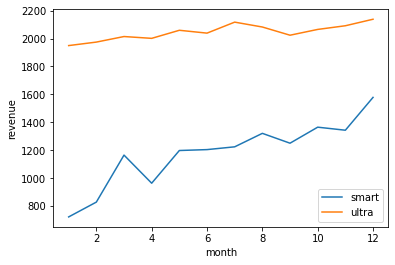

In [79]:
#график средней выручки по месяцам для наглядности
users_monthly_activity.query('tariff == "smart"').groupby(by = 'month').mean()['revenue'].plot(legend = True, label = 'smart')
users_monthly_activity.query('tariff == "ultra"').groupby(by = 'month').mean()['revenue'].plot(legend = True, ylabel = 'revenue', label = 'ultra')
plt.show()

<div style="border:solid Orange 2px; padding: 40px">
<div class="alert alert-warning">
    <h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<font color='Orange'><b>Некоторые рекомендации 💡:</b> </font>
        
На легенде графика не понятно, где тариф smart, а где ultra.
        
</div>

#### Правка 5
<div class = "alert alert-info" style="border-left: 14px solid blue">
<b>Комментарий студента</b>
    
Исправил</div>

<div style="border:solid Green 2px; padding: 40px">
<div class="alert alert-success">
<h3> Комментарий ревьюера_V2 <a class="tocSkip"> </h3>

<font color='green'><b>Все отлично! 👍:</b>  </font>

👍
    
</div>

<AxesSubplot:>

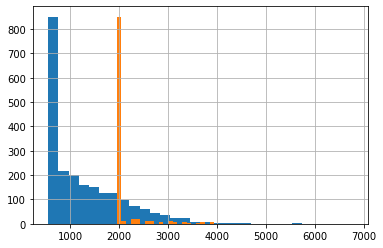

In [80]:
#распределение выручки по тарифам без усреднения
users_monthly_activity.query('tariff == "smart"')['revenue'].hist(bins = 30)
users_monthly_activity.query('tariff == "ultra"')['revenue'].hist(bins = 30)

<AxesSubplot:>

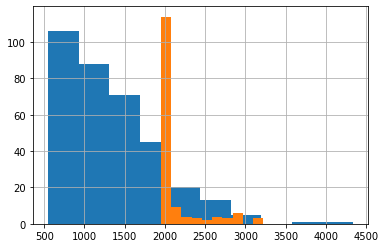

In [81]:
#распределение выручки по тарифам с усреднением по абонентам
users_monthly_activity.query('tariff == "smart"').groupby(by = 'user_id').mean()['revenue'].hist()
users_monthly_activity.query('tariff == "ultra"').groupby(by = 'user_id').mean()['revenue'].hist()

In [82]:
mean_revenue_by_user = users_monthly_activity.pivot_table(
    index = 'user_id', values = 'revenue', aggfunc = 'mean')
mean_revenue_by_user = mean_revenue_by_user.join(user_tariffs, how = 'outer')
mean_revenue_by_user

,revenue,tariff
user_id,,
1000,1950.000000,ultra
1001,850.000000,smart
1002,1035.714286,smart
1003,1950.000000,ultra
1004,1950.000000,ultra
...,...,...
1495,2310.000000,ultra
1496,2362.583333,smart
1497,928.333333,smart


In [83]:
users_monthly_activity.query('user_id == 1497')
#проверяю, действительно ли это среднее.

,month,user_id,calls_count,calls_duration,msg_sent,gb_used,tariff,revenue,age,churn_date,city,first_name,last_name,reg_date,users_by_date,revenue_if_smart
3093,10.0,1497,50.0,490.0,20.0,12.0,smart,550.0,32,NaT,Челябинск,Каролина,Агеева,2018-10-09,395.0,550.0
3094,11.0,1497,48.0,371.0,14.0,14.0,smart,550.0,32,NaT,Челябинск,Каролина,Агеева,2018-10-09,395.0,550.0
3095,12.0,1497,58.0,545.0,17.0,20.0,smart,1685.0,32,NaT,Челябинск,Каролина,Агеева,2018-10-09,395.0,1685.0


<AxesSubplot:title={'center':'revenue'}>

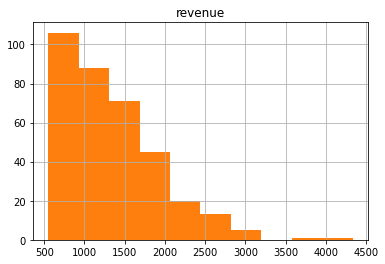

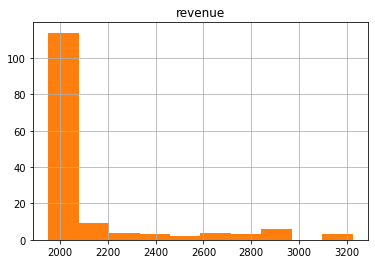

In [84]:
mean_revenue_by_user[mean_revenue_by_user['tariff'] == 'smart'].hist()
users_monthly_activity.query('tariff == "smart"').groupby(by = 'user_id').mean()['revenue'].hist()

mean_revenue_by_user[mean_revenue_by_user['tariff'] == 'ultra'].hist()
users_monthly_activity.query('tariff == "ultra"').groupby(by = 'user_id').mean()['revenue'].hist()

#что так, что так - графики идентичные, получается усреднили правильно

In [85]:
display(users_monthly_activity.query('tariff == "smart"').groupby(by = 'user_id').mean()['revenue'].describe())
display(users_monthly_activity.query('tariff == "ultra"').groupby(by = 'user_id').mean()['revenue'].describe())
#Стандартное отклонение отличается в 2 раза, тогда дисперсия - в четыре.

count     350.000000
mean     1324.401019
std       606.040551
min       550.000000
25%       867.550000
50%      1177.116667
75%      1667.250000
max      4333.333333
Name: revenue, dtype: float64

count     148.000000
mean     2086.464659
std       298.532720
min      1950.000000
25%      1950.000000
50%      1950.000000
75%      1990.625000
max      3225.000000
Name: revenue, dtype: float64

In [87]:
#Нулевой гипотезой будет, что средняя выручка пользователей разных тарифов не различаются.
#Альтернативная гипотеза - средняя выручка пользователей по тарифам различается.
#У нас две независимые выборки, которые являются выборками
#Как мы проверили выше, дисперсия у них разная.
# scipy.stats.ttest_ind (array1, array2, equal_var) - наш вариант
#
alpha = 0.01
results = st.ttest_ind(users_monthly_activity.query('tariff == "smart"')['revenue'], 
                       users_monthly_activity.query('tariff == "ultra"')['revenue'],
                       equal_var = False)
print('P-value:', results.pvalue)

if (results.pvalue < alpha):
    print("Отвергаем нулевую гипотезу")
else:
    print("Не получилось отвергнуть нулевую гипотезу")
#Получив такое низкое P-value, я начинаю сомневаться, что правильно сделал выборки по выручке, хотя перепроверил несколько раз

P-value: 4.2606313931076085e-250
Отвергаем нулевую гипотезу


<div style="border:solid Red 2px; padding: 40px">
<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>

    
<b>На доработку ❌:</b> 
    
Не нужно предварительно усреднять данные по каждому клиенту. Необходимо работать с сырым массивом данных. Слово средняя означает, что сам метод сравнения стат.гипотез будет вычислять среднюю. Т.е. сам метод критерии Стьюдента работает так, что он проверяет средние. Он производит усреднение внутри себя. 
    
Добавь формулировку альтернативной гипотезы.
    
</div>

<div class="alert alert-info"> <b>Комментарий студента:</b> 

Cредняя выручка пользователей тарифов «Ультра» и «Смарт» различаются с вероятностью более 99% (потому что выбрали альфа 0.01).
</div>

#### Правка 6
<div class = "alert alert-info" style="border-left: 14px solid blue">
<b>Комментарий студента</b>
    
Исправил</div>

<div style="border:solid Green 2px; padding: 40px">
<div class="alert alert-success">
<h3> Комментарий ревьюера_V2 <a class="tocSkip"> </h3>

<font color='green'><b>Все отлично! 👍:</b>  </font>

Отлично. Теперь в проверке гипотез вывод верный.
    
</div>

count     611.000000
mean     1546.713584
std       752.088071
min       550.000000
25%       780.500000
50%      1750.000000
75%      1950.000000
max      5321.000000
Name: revenue, dtype: float64

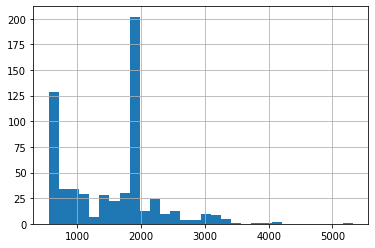

In [89]:
users_monthly_activity.query('city == "Москва"')['revenue'].hist(bins = 30)
users_monthly_activity.query('city == "Москва"')['revenue'].describe()

count    2603.000000
mean     1524.936227
std       808.787752
min       550.000000
25%       750.000000
50%      1583.000000
75%      1950.000000
max      6770.000000
Name: revenue, dtype: float64

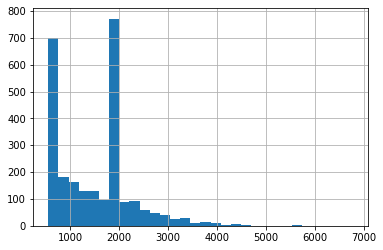

In [90]:
users_monthly_activity.query('city != "Москва"')['revenue'].hist(bins = 30)
users_monthly_activity.query('city != "Москва"')['revenue'].describe()

#### Правка 7

#Нулевой гипотезой будет, что средняя выручка абонентов из Москвы не отличается от абонентов других городов. 
#У нас есть среднее по москве и распределение, похожее на нормальное.
interested_value = 1546.713584 #среднее по Москве
alpha = 0.05 
#интуитивно хочется увеличить значение альфа, потому что выборка маленькая, 
#нет веры, что можно такие узкие коридоры задавать на таких маленьких выборках
#как уже упоминалось ранее, поскольку мы используем только выборку из генеральной совокупности, 
#с, предположительно, неравной дисперсией то используетм т-тест

results = st.ttest_1samp(
    users_monthly_activity.query('city != "Москва"').groupby(by = 'city').mean()['revenue'], #средняя выручка по другим городам
    interested_value)

print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print("Отвергаем нулевую гипотезу")
else:
    print("Не получилось отвергнуть нулевую гипотезу") 

<div style="border:solid Red 2px; padding: 40px">
<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>

    
<b>На доработку ❌:</b> 
    
Здесь такие же замечания:
    
Добавь формулировку альтернативной гипотезы.

Нам не нужно делать группировку и считать средние, достаточно просто отобрать выручку по Ультре \ Смарту (Москве \ не Москве) и передать выборки в статистический тест.
    
</div> 

In [95]:
#Нулевой гипотезой будет, что средняя выручка абонентов из Москвы не отличается от абонентов других городов.
#альтернативной гипотезой является, что средняя выручка абонентов из Москвы отличается от абонентов других городов

alpha = 0.05 
#интуитивно хочется увеличить значение альфа, потому что выборка маленькая, 
#нет веры, что можно такие узкие коридоры задавать на таких маленьких выборках
#как уже упоминалось ранее, поскольку мы используем только выборку из генеральной совокупности, 
#а так же стоит отметиь, что дисперсии близки, но все же не равны  



results = st.ttest_ind(users_monthly_activity.query('city == "Москва"')['revenue'], 
                       users_monthly_activity.query('city != "Москва"')['revenue'],
                       equal_var = False)
print('P-value:', results.pvalue)

if (results.pvalue < alpha):
    print("Отвергаем нулевую гипотезу")
else:
    print("Не получилось отвергнуть нулевую гипотезу")



P-value: 0.5257376663729298
Не получилось отвергнуть нулевую гипотезу


<div class="alert alert-info"> <b>Комментарий студента:</b> 
Такое низкое p-значение показывает низукую вероятность события, что в Москве средня выручка с абонента в месяц отличается от среднего по другим городам.
    
</div>

<div style="border:solid Green 2px; padding: 40px">
<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<font color='green'><b>Все отлично! 👍:</b>  </font>

Верно выбран двусторонний тест. Отлично, что выводишь значение `results.pvalue`, в случае, если оно расчиталось не верно (например, равно NaN) - это можно сразу увидеть.
    
    
</div>

In [74]:
#посмотрим ещё пару вещей, чтобы было о чем написать в выодах

mean_revenue_by_tariff = users_monthly_activity.pivot_table(
    index = 'tariff', values = 'revenue', aggfunc = 'sum')
mean_revenue_by_tariff['percent_to_total'] = mean_revenue_by_tariff['revenue']/mean_revenue_by_tariff.sum()['revenue']
display(mean_revenue_by_tariff)
user_count_by_tariff = users_monthly_activity.pivot_table(
    index = 'tariff', values = 'user_id', aggfunc = 'count')
user_count_by_tariff['percent_to_total'] = user_count_by_tariff['user_id']/user_count_by_tariff.sum()['user_id']
user_count_by_tariff

,revenue,percent_to_total
tariff,,
smart,2875351.0,0.585081
ultra,2039100.0,0.414919


,user_id,percent_to_total
tariff,,
smart,2229,0.693528
ultra,985,0.306472


In [75]:
#посчитаем, какой процент пользователей тарифов доплачивает за услуги сверх плана
print('доп оплата на тарифе смарт', users_monthly_activity.query('tariff == "smart" and revenue > 550').count()['user_id']/user_count_by_tariff.loc['smart','user_id'])
print('доп оплата на тарифе ультра', users_monthly_activity.query('tariff == "ultra" and revenue > 1950').count()['user_id']/user_count_by_tariff.loc['ultra','user_id'])

доп оплата на тарифе смарт 0.7456258411843876
доп оплата на тарифе ультра 0.13604060913705585


## Общий вывод

<div class="alert alert-info"> <b>Комментарий студента:</b> 

1) 30% абонентов подключают тариф 'Ультра' и приносят 41.5% от общей выручки. При этом лишь 13.6% из них используют платные опции сверх включенного пакета. В их случае это всегда дополнительные траты на интернет. При этом никто из пользователей тарифа полностью не потребляет пакет сообщений и звонков.
    
2) 70% абонентов подключают тариф "Смарт" и приносят 58.5% прибыли. При этом 74.6% из них докупают дополнительные услуги. 75% абонентов тарифа укладываются в лимит сообшений, в лимит звонков укладываются порядка 60% и лишь 40% (примерно) укладываются в лимит по интернет-трафику.
    
3) Дисперсии параметров тарифа ультра выше, чем у тарифа смарт, что говорит о большей разнице в привычках между абонентами-пользователями пакетов ультра, чем в пакете смарт.
    
4) Среднее потребление услуг по категориям выше у тарифа "ультра" на 20-30%, при этом цена на этот тариф выше в 3.5 раза.

5) Статистически однозначно, что средняя выручка с пользователей по тарифам отличается. Исходя из полученных данных, средняя выручка от пользователей тарифа "ультра" всегда выше.
    
6) Опровергнуть гипотезу, что средняя выручка на абонента в Москве отличается от других городов не получилось.
    
7) Чаще всего пользователи докупают доступ в интернет, реже звонки и очень редко смс-сообщения.
    
    
    
    
</div>

<div style="border:solid Red 2px; padding: 40px">
<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>
    
<b>На доработку ❌:</b> 
    
Вывод должен содержать ответ на главный вопрос задачи - определение перспективного тарифа для телеком-компании. В твоем выводе это размыто.

> Нужно проанализировать поведение клиентов и сделать вывод — какой тариф лучше.
    
В итоге, какой тариф перспективней?
    
</div>

#### Правка 8
<div class = "alert alert-info" style="border-left: 14px solid blue">
<b>Комментарий студента</b>
    
8) Расчеты показывают, что при пересчете потребления услуг пользователей с тарифом "ультра" по трафиной сетке "смарт" общая выручка от абонентов по году увеличится на 4.7%
    
9) Несморя на более низкую абоненскую плату, более чем в 60% случаев пользователи потребляют более 15 Гб интернета, но лишь в 4.7% случаев потребляют более 30Гб интернета. Таким образом, заложенные 30 Гб интернета в тариф ультра при пересчете на тариф "смарт" являются дополнительными (30 - 15) * 200 = 3000 рублей в месяц, которые могли бы доплатить пользователи.
    
10) Исходя из вышеперечисленного, более перспективным для компании «Мегалайн» является более массовый тариф "Смарт". 
</div>

<div style="border:solid Green 2px; padding: 40px">
<div class="alert alert-success">
<h3> Комментарий ревьюера_V2 <a class="tocSkip"> </h3>

<font color='green'><b>Все отлично! 👍:</b>  </font>

Молодец. Основные моменты в выводах учтены. Теперь общий вывод отвечает на поставленный в задаче вопрос. 
    
</div>

<div style="border:solid Chocolate 2px; padding: 40px">

**Общий вывод по проекту**

Дмитрий, спасибо за твой проект! Проделана большая работа, и видно как внимательно ты отнесся к содержанию анализа и к оформлению. Ты большой молодец! Все ключевые этапы работы над проектом выполнены, код логичен и понятен, комментарии и выводы написаны, так что в целом справиться с задачей тебе удалось. Возле моментов, на которые стоит обратить внимание, я оставила комментарии.
    
**Отдельно хочу отметить положительные моменты в твоей работе:**
    
* Очень хорошо расписаны комментарии и план решения на каждом этапе проекта, становится понятен твой ход мысли. В будущем при необходимости вернуться к проекту, тебе самому будет легко вспомнить, чем ты руководствовался.
* На всех этапах ты предлагал интересные решения и методы для их реализации.
* Ты активно использовал визуализацию. Это здорово, т.к. помогает быстро считать информацию получателю отчета.
* Ты грамотно делаешь выводы, на основе полученной информации.
  

**Моменты, требующие внимания:**
    
* Добавь в шаг 3 анализ выручки.  
* Скорректируй проверку гипотез.
* Скорректируй итоговый вывод.
* Остальные рекомендации ты найдешь в моих комментариях!  
    

    
**Желаю удачи и жду твой проект на повторное ревью!**   


<div class = "alert alert-info" style="border-left: 14px solid blue">
<b>Комментарий студента</b>
    
Добрый день! Все скорректировал. Добавил ссылки в оглавление.
</div>

<div style="border:solid Green 2px; padding: 40px">
<h3> Комментарий ревьюера_V2 <a class="tocSkip"> </h3>

Спасибо за доработку. Проект принят. Желаю удачи в дальнейшем обучении.
    
</div>